<a href="https://colab.research.google.com/github/KAVINKUMARP11/Marketing-research-methods---KAVIN-KUMAR-P-_-Jio-Institute/blob/main/mediumperfume.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving ebay_mens_perfume.csv to ebay_mens_perfume (1).csv


<ipython-input-1-6d4fc39d8100>:18: FutureWarning: Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')
<ipython-input-1-6d4fc39d8100>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='demand_category', palette="coolwarm")


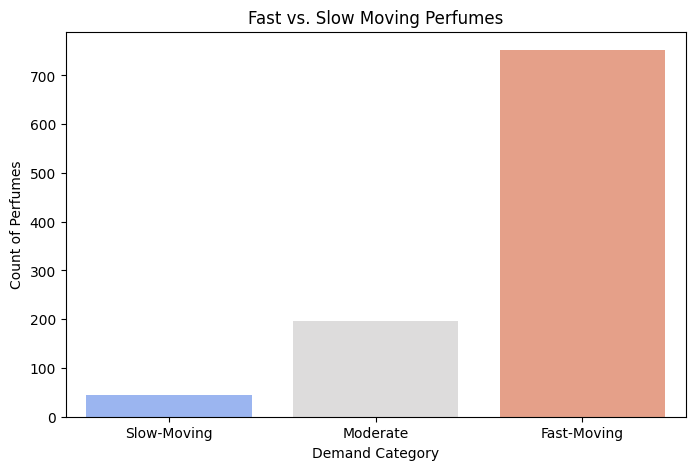

Top 10 perfumes with highest stock turnover:
                                                 title               brand  \
374  L'Homme by Yves Saint Laurent YSL 3.3 / 3.4 oz...  Yves Saint Laurent   
577  12 Dolce & Gabbana The One Luminous Night Excl...       Dolce&Gabbana   
703  Perfume for Men's Valentine Milano Cologne 3.4...   Fragrance Couture   
241  Acqua Di Gio by Giorgio Armani 6.7 oz Spray Ea...      Giorgio Armani   
988  Michael Jordan by Michael Jordan 3.4 oz Cologn...      Michael Jordan   
94   Y by Yves Saint Laurent YSL 3.3 / 3.4 oz EDP C...  Yves Saint Laurent   
242  1 Million by Paco Rabanne 3.4 oz EDT Cologne f...        Paco Rabanne   
249  Dossier Musky Oakmoss Eau de Parfum. Size: 50m...             Dossier   
593  Insurrection II Wild 3.0 oz By Reyane Traditio...    Reyane Tradition   
592  Insurrection II Sport by Reyane Tradition colo...    Reyane Tradition   

     stock_turnover  
374             1.0  
577             1.0  
703             1.0  
241     

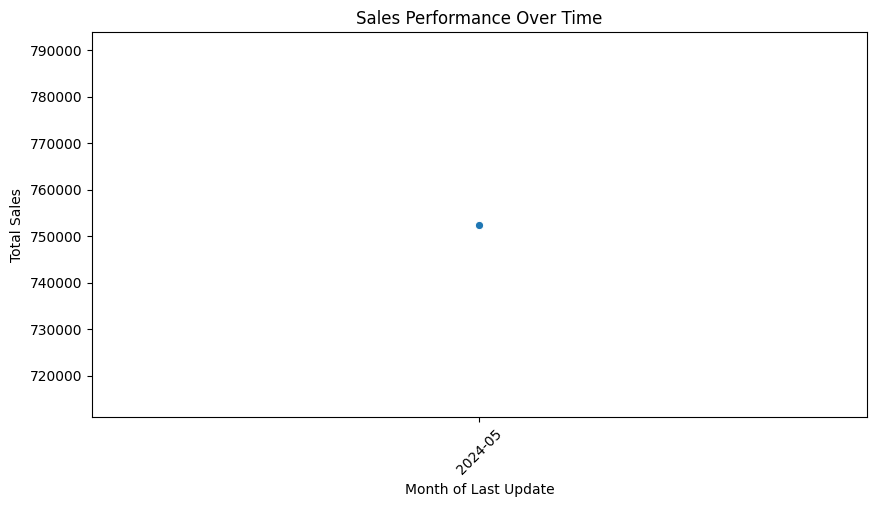

Recent Listing Sales Performance Summary:
           sold
count       1.0
mean   752465.0
std         NaN
min    752465.0
25%    752465.0
50%    752465.0
75%    752465.0
max    752465.0


In [ ]:
# Install required libraries (if not already installed)
!pip install pandas numpy matplotlib seaborn

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload the dataset (Make sure you upload your file first)
from google.colab import files
uploaded = files.upload()

# Load the dataset (Replace with your filename)
df = pd.read_csv("ebay_mens_perfume.csv")

# Convert lastUpdated to datetime format
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

# Fill missing values in 'available' and 'sold' with 0
df['available'] = df['available'].fillna(0)
df['sold'] = df['sold'].fillna(0)

### 1. Identify Fast-Moving vs. Slow-Moving Perfumes ###
# Define a metric: Sold Quantity / Available Stock to categorize fast vs. slow
df['sell_rate'] = df['sold'] / (df['sold'] + df['available'])

# Classify products based on sell rate
df['demand_category'] = pd.cut(df['sell_rate'], bins=[0, 0.3, 0.7, 1], labels=['Slow-Moving', 'Moderate', 'Fast-Moving'])

# Plot Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='demand_category', palette="coolwarm")
plt.title("Fast vs. Slow Moving Perfumes")
plt.xlabel("Demand Category")
plt.ylabel("Count of Perfumes")
plt.show()

### 2. Stock Turnover Rate Calculation ###
# Stock Turnover Rate = Sales / Initial Stock
df['stock_turnover'] = df['sold'] / (df['sold'] + df['available'])

# Display top perfumes with highest turnover
top_turnover = df[['title', 'brand', 'stock_turnover']].sort_values(by='stock_turnover', ascending=False)
print("Top 10 perfumes with highest stock turnover:")
print(top_turnover.head(10))

### 3. New Listings vs. Sales Performance ###
# Extract the month of last update for analysis
df['lastUpdated_month'] = df['lastUpdated'].dt.to_period('M')

# Group by month to compare recent listings vs. sales
monthly_sales = df.groupby('lastUpdated_month')['sold'].sum().reset_index()

# Plot Monthly Sales Performance
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales['lastUpdated_month'].astype(str), y=monthly_sales['sold'], marker='o')
plt.xticks(rotation=45)
plt.title("Sales Performance Over Time")
plt.xlabel("Month of Last Update")
plt.ylabel("Total Sales")
plt.show()

# Print summary statistics
print("Recent Listing Sales Performance Summary:")
print(monthly_sales.describe())



Saving ebay_mens_perfume.csv to ebay_mens_perfume (2).csv


<ipython-input-2-afdf3ef761b4>:19: FutureWarning: Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')


<ipython-input-2-afdf3ef761b4>:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




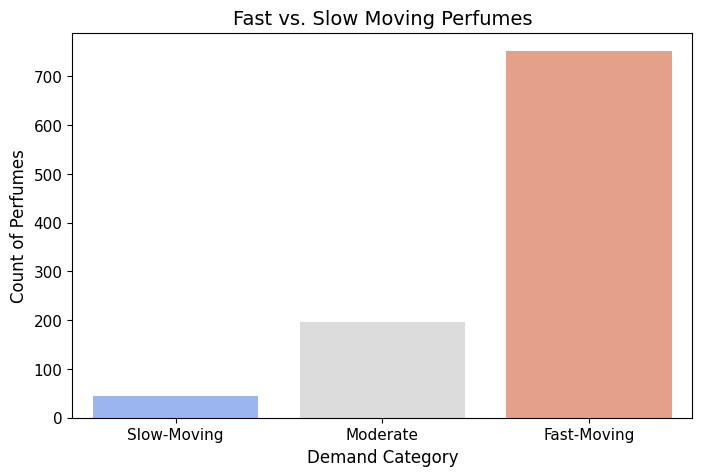

TypeError: Type is not JSON serializable: Period

In [ ]:
# Install necessary libraries (if not already installed)
!pip install pandas numpy matplotlib seaborn plotly

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (Replace with your filename)
df = pd.read_csv("ebay_mens_perfume.csv")

# Convert lastUpdated to datetime format
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

# Fill missing values in 'available' and 'sold' with 0
df['available'] = df['available'].fillna(0)
df['sold'] = df['sold'].fillna(0)

### 1. Identify Fast-Moving vs. Slow-Moving Perfumes ###
df['sell_rate'] = df['sold'] / (df['sold'] + df['available'])
df['demand_category'] = pd.cut(df['sell_rate'], bins=[0, 0.3, 0.7, 1], labels=['Slow-Moving', 'Moderate', 'Fast-Moving'])

# Create a high-quality Pie Chart using Plotly
fig = px.pie(df, names='demand_category', title='Fast vs. Slow Moving Perfumes', hole=0.3, color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()

# Create a high-quality Seaborn Bar Plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='demand_category', palette="coolwarm")
plt.title("Fast vs. Slow Moving Perfumes", fontsize=14)
plt.xlabel("Demand Category", fontsize=12)
plt.ylabel("Count of Perfumes", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

### 2. Stock Turnover Rate Calculation ###
df['stock_turnover'] = df['sold'] / (df['sold'] + df['available'])

# Top 10 perfumes with highest turnover
top_turnover = df[['title', 'brand', 'stock_turnover']].sort_values(by='stock_turnover', ascending=False).head(10)

# Create a horizontal bar chart using Plotly
fig = px.bar(top_turnover, x='stock_turnover', y='title', color='brand', title='Top 10 Perfumes by Stock Turnover Rate',
             labels={'stock_turnover': 'Stock Turnover Rate', 'title': 'Perfume'},
             orientation='h', color_discrete_sequence=px.colors.sequential.Viridis)
fig.show()

### 3. New Listings vs. Sales Performance ###
df['lastUpdated_month'] = df['lastUpdated'].dt.to_period('M')

# Group by month to compare recent listings vs. sales
monthly_sales = df.groupby('lastUpdated_month')['sold'].sum().reset_index()

# Create an interactive time-series chart with Plotly
fig = px.line(monthly_sales, x='lastUpdated_month', y='sold', markers=True, title="Sales Performance Over Time",
              labels={'lastUpdated_month': 'Month', 'sold': 'Total Sales'},
              line_shape='spline', color_discrete_sequence=['blue'])
fig.update_traces(marker=dict(size=8, symbol="circle"))
fig.show()

# Print summary statistics
print("Recent Listing Sales Performance Summary:")
print(monthly_sales.describe())



Saving ebay_mens_perfume.csv to ebay_mens_perfume (3).csv


<ipython-input-3-0e40b4f51bc5>:19: FutureWarning:

Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.



<ipython-input-3-0e40b4f51bc5>:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




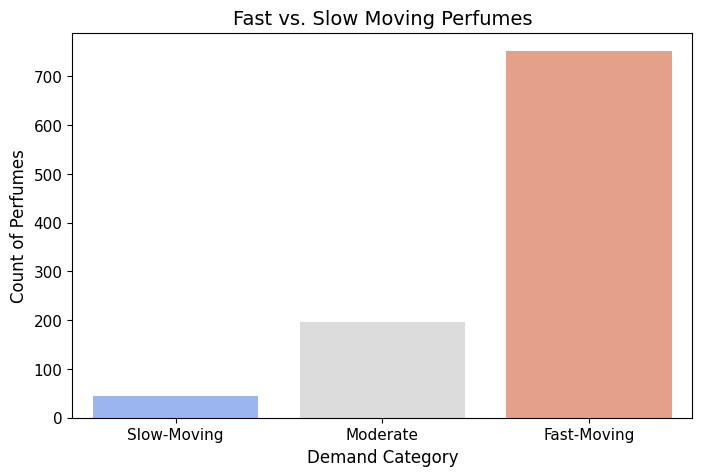

Recent Listing Sales Performance Summary:
           sold
count       1.0
mean   752465.0
std         NaN
min    752465.0
25%    752465.0
50%    752465.0
75%    752465.0
max    752465.0


In [ ]:
# Install necessary libraries (if not already installed)
!pip install pandas numpy matplotlib seaborn plotly

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (Replace with your filename)
df = pd.read_csv("ebay_mens_perfume.csv")

# Convert lastUpdated to datetime format
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

# Fill missing values in 'available' and 'sold' with 0
df['available'] = df['available'].fillna(0)
df['sold'] = df['sold'].fillna(0)

### 1. Identify Fast-Moving vs. Slow-Moving Perfumes ###
df['sell_rate'] = df['sold'] / (df['sold'] + df['available'])
df['demand_category'] = pd.cut(df['sell_rate'], bins=[0, 0.3, 0.7, 1], labels=['Slow-Moving', 'Moderate', 'Fast-Moving'])

# Create a high-quality Pie Chart using Plotly
fig = px.pie(df, names='demand_category', title='Fast vs. Slow Moving Perfumes', hole=0.3, color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()

# Create a high-quality Seaborn Bar Plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='demand_category', palette="coolwarm")
plt.title("Fast vs. Slow Moving Perfumes", fontsize=14)
plt.xlabel("Demand Category", fontsize=12)
plt.ylabel("Count of Perfumes", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

### 2. Stock Turnover Rate Calculation ###
df['stock_turnover'] = df['sold'] / (df['sold'] + df['available'])

# Top 10 perfumes with highest turnover
top_turnover = df[['title', 'brand', 'stock_turnover']].sort_values(by='stock_turnover', ascending=False).head(10)

# Create a horizontal bar chart using Plotly
fig = px.bar(top_turnover, x='stock_turnover', y='title', color='brand', title='Top 10 Perfumes by Stock Turnover Rate',
             labels={'stock_turnover': 'Stock Turnover Rate', 'title': 'Perfume'},
             orientation='h', color_discrete_sequence=px.colors.sequential.Viridis)
fig.show()

### 3. New Listings vs. Sales Performance ###
df['lastUpdated_month'] = df['lastUpdated'].dt.to_period('M')

# Group by month to compare recent listings vs. sales
monthly_sales = df.groupby('lastUpdated_month')['sold'].sum().reset_index()

# Convert 'lastUpdated_month' to string before plotting
monthly_sales['lastUpdated_month'] = monthly_sales['lastUpdated_month'].astype(str)

# Create an interactive time-series chart with Plotly
fig = px.line(monthly_sales, x='lastUpdated_month', y='sold', markers=True, title="Sales Performance Over Time",
              labels={'lastUpdated_month': 'Month', 'sold': 'Total Sales'},
              line_shape='spline', color_discrete_sequence=['blue'])
fig.update_traces(marker=dict(size=8, symbol="circle"))
fig.show()

# Print summary statistics
print("Recent Listing Sales Performance Summary:")
print(monthly_sales.describe())


In [ ]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn plotly prophet

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from fbprophet import Prophet

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (Replace with your filename)
df = pd.read_csv("/content/ebay_mens_perfume.csv")

# Convert lastUpdated to datetime format
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

# Fill missing values in 'available', 'sold', and 'price' with 0
df['available'] = df['available'].fillna(0)
df['sold'] = df['sold'].fillna(0)
df['price'] = df['price'].fillna(df['price'].median())  # Fill price with median

### 1. Sales Trend Over Time ###
sales_trend = df.groupby(df['lastUpdated'].dt.date)['sold'].sum().reset_index()
sales_trend.columns = ['Date', 'Total Sales']

# Plot Sales Trend Over Time
fig = px.line(sales_trend, x='Date', y='Total Sales', markers=True, title="Sales Trend Over Time",
              labels={'Date': 'Date', 'Total Sales': 'Units Sold'},
              line_shape='spline', color_discrete_sequence=['blue'])
fig.update_traces(marker=dict(size=8, symbol="circle"))
fig.show()

### 2. Stock Trends Over Time ###
stock_trend = df.groupby(df['lastUpdated'].dt.date)['available'].sum().reset_index()
stock_trend.columns = ['Date', 'Total Available Stock']

# Plot Stock Trend Over Time
fig = px.line(stock_trend, x='Date', y='Total Available Stock', markers=True, title="Stock Trend Over Time",
              labels={'Date': 'Date', 'Total Available Stock': 'Stock Available'},
              line_shape='spline', color_discrete_sequence=['red'])
fig.update_traces(marker=dict(size=8, symbol="circle"))
fig.show()

### 3. Price Trends Over Time ###
price_trend = df.groupby(df['lastUpdated'].dt.date)['price'].mean().reset_index()
price_trend.columns = ['Date', 'Average Price']

# Plot Price Trend Over Time
fig = px.line(price_trend, x='Date', y='Average Price', markers=True, title="Price Trend Over Time",
              labels={'Date': 'Date', 'Average Price': 'Avg Price ($)'},
              line_shape='spline', color_discrete_sequence=['green'])
fig.update_traces(marker=dict(size=8, symbol="circle"))
fig.show()

### 4. Seasonality Analysis ###
df['month'] = df['lastUpdated'].dt.month
seasonality_sales = df.groupby('month')['sold'].sum().reset_index()

# Plot Seasonal Sales Trends
fig = px.bar(seasonality_sales, x='month', y='sold', title="Seasonality in Sales (Monthly)",
             labels={'month': 'Month', 'sold': 'Total Sales'},
             color='sold', color_continuous_scale='blues')
fig.show()

### 5. Rolling Average of Sales ###
sales_trend['Rolling_Avg'] = sales_trend['Total Sales'].rolling(window=7).mean()

# Plot Rolling Average
fig = px.line(sales_trend, x='Date', y='Rolling_Avg', markers=True, title="Rolling Average of Sales (7 Days)",
              labels={'Date': 'Date', 'Rolling_Avg': '7-Day Average Sales'},
              line_shape='spline', color_discrete_sequence=['purple'])
fig.update_traces(marker=dict(size=8, symbol="circle"))
fig.show()

### 6. Forecasting Sales with Prophet ###
# Prepare Data for Prophet
forecast_df = sales_trend.rename(columns={'Date': 'ds', 'Total Sales': 'y'})

# Initialize Prophet model
model = Prophet()
model.fit(forecast_df)

# Create future dates for prediction (next 60 days)
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

# Plot forecast
fig = model.plot(forecast)
plt.title("Forecasting Future Sales (Prophet Model)")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.show()


ModuleNotFoundError: No module named 'fbprophet'

In [ ]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn plotly prophet

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from prophet import Prophet  # Corrected import

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (Replace with your filename)
df = pd.read_csv("ebay_mens_perfume.csv")

# Convert lastUpdated to datetime format
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

# Fill missing values in 'available', 'sold', and 'price' with 0
df['available'] = df['available'].fillna(0)
df['sold'] = df['sold'].fillna(0)
df['price'] = df['price'].fillna(df['price'].median())  # Fill price with median

### 1. Sales Trend Over Time ###
sales_trend = df.groupby(df['lastUpdated'].dt.date)['sold'].sum().reset_index()
sales_trend.columns = ['Date', 'Total Sales']

# Plot Sales Trend Over Time
fig = px.line(sales_trend, x='Date', y='Total Sales', markers=True, title="Sales Trend Over Time",
              labels={'Date': 'Date', 'Total Sales': 'Units Sold'},
              line_shape='spline', color_discrete_sequence=['blue'])
fig.update_traces(marker=dict(size=8, symbol="circle"))
fig.show()

### 2. Stock Trends Over Time ###
stock_trend = df.groupby(df['lastUpdated'].dt.date)['available'].sum



Saving ebay_mens_perfume.csv to ebay_mens_perfume (5).csv


<ipython-input-6-f37c9f23cd68>:20: FutureWarning:

Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.



In [ ]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn plotly

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (Replace with your filename)
df = pd.read_csv("ebay_mens_perfume.csv")

# Convert lastUpdated to datetime format
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

# Fill missing values in 'available' with 0
df['available'] = df['available'].fillna(0)

### 1. Stock Trends Over Time (Overall) ###
stock_trend = df.groupby(df['lastUpdated'].dt.date)['available'].sum().reset_index()
stock_trend.columns = ['Date', 'Total Available Stock']

# Plot Stock Trend Over Time (Overall)
fig = px.line(stock_trend, x='Date', y='Total Available Stock', markers=True, title="Stock Trend Over Time (Overall)",
              labels={'Date': 'Date', 'Total Available Stock': 'Stock Available'},
              line_shape='spline', color_discrete_sequence=['red'])
fig.update_traces(marker=dict(size=8, symbol="circle"))
fig.show()

### 2. Stock Trends for Top-Selling Perfumes ###
# Identify Top 5 Best-Selling Perfumes
top_perfumes = df.groupby('title')['sold'].sum().reset_index().sort_values(by='sold', ascending=False).head(5)

# Filter data for only the Top 5 Perfumes
top_perfume_list = top_perfumes['title'].tolist()
top_stock_trend = df[df['title'].isin(top_perfume_list)]

# Aggregate available stock for top perfumes over time
top_stock_trend = top_stock_trend.groupby(['lastUpdated', 'title'])['available'].sum().reset_index()

# Plot Stock Trend for Top Perfumes
fig = px.line(top_stock_trend, x='lastUpdated', y='available', color='title', markers=True,
              title="Stock Trends for Top 5 Best-Selling Perfumes",
              labels={'lastUpdated': 'Date', 'available': 'Stock Available', 'title': 'Perfume'},
              line_shape='spline')
fig.update_traces(marker=dict(size=6, symbol="circle"))
fig.show()



Saving ebay_mens_perfume.csv to ebay_mens_perfume (6).csv


<ipython-input-7-e189667208f8>:19: FutureWarning:

Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.



In [ ]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn plotly

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (Replace with your filename)
df = pd.read_csv("ebay_mens_perfume.csv")

# Convert lastUpdated to datetime format
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

# Fill missing values in 'price' with median price
df['price'] = df['price'].fillna(df['price'].median())

### 1. Overall Price Trends Over Time ###
price_trend = df.groupby(df['lastUpdated'].dt.date)['price'].mean().reset_index()
price_trend.columns = ['Date', 'Average Price']

# Plot Overall Price Trend
fig = px.line(price_trend, x='Date', y='Average Price', markers=True, title="Price Trend Over Time",
              labels={'Date': 'Date', 'Average Price': 'Avg Price ($)'},
              line_shape='spline', color_discrete_sequence=['green'])
fig.update_traces(marker=dict(size=8, symbol="circle"))
fig.show()

### 2. Price Trends for Top Brands ###
# Identify Top 5 Brands Based on Sales
top_brands = df.groupby('brand')['sold'].sum().reset_index().sort_values(by='sold', ascending=False).head(5)

# Filter data for Top 5 Brands
top_brand_list = top_brands['brand'].tolist()
brand_price_trend = df[df['brand'].isin(top_brand_list)]

# Aggregate average price over time per brand
brand_price_trend = brand_price_trend.groupby(['lastUpdated', 'brand'])['price'].mean().reset_index()

# Plot Brand-Specific Price Trends
fig = px.line(brand_price_trend, x='lastUpdated', y='price', color='brand', markers=True,
              title="Price Trends for Top 5 Best-Selling Brands",
              labels={'lastUpdated': 'Date', 'price': 'Average Price ($)', 'brand': 'Brand'},
              line_shape='spline')
fig.update_traces(marker=dict(size=6, symbol="circle"))
fig.show()

### 3. Price Trends by Perfume Type ###
# Filter Data by Type (Eau de Parfum, Eau de Toilette, etc.)
type_price_trend = df.groupby(['lastUpdated', 'type'])['price'].mean().reset_index()

# Plot Type-Specific Price Trends
fig = px.line(type_price_trend, x='lastUpdated', y='price', color='type', markers=True,
              title="Price Trends by Perfume Type",
              labels={'lastUpdated': 'Date', 'price': 'Average Price ($)', 'type': 'Perfume Type'},
              line_shape='spline')
fig.update_traces(marker=dict(size=6, symbol="circle"))
fig.show()


Saving ebay_mens_perfume.csv to ebay_mens_perfume (7).csv


<ipython-input-8-368867022342>:19: FutureWarning:

Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.



In [ ]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn plotly

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (Replace with your filename)
df = pd.read_csv("ebay_mens_perfume.csv")

# Convert lastUpdated to datetime format
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

# Fill missing values in 'sold' with 0
df['sold'] = df['sold'].fillna(0)

### 1. Monthly Seasonality in Sales ###
df['month'] = df['lastUpdated'].dt.month
seasonality_sales = df.groupby('month')['sold'].sum().reset_index()

# Plot Monthly Sales Trends
fig = px.bar(seasonality_sales, x='month', y='sold', title="Seasonality in Sales (Monthly)",
             labels={'month': 'Month', 'sold': 'Total Sales'},
             color='sold', color_continuous_scale='blues')
fig.show()

### 2. Weekly Sales Trends ###
df['weekday'] = df['lastUpdated'].dt.day_name()
weekday_sales = df.groupby('weekday')['sold'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).reset_index()

# Plot Sales by Weekday
fig = px.bar(weekday_sales, x='weekday', y='sold', title="Sales Trends by Weekday",
             labels={'weekday': 'Day of the Week', 'sold': 'Total Sales'},
             color='sold', color_continuous_scale='viridis')
fig.show()

### 3. Holiday Season Sales Analysis ###
# Extract holiday months (November, December for Christmas season)
holiday_sales = df[df['month'].isin([11, 12])].groupby(df['lastUpdated'].dt.date)['sold'].sum().reset_index()
holiday_sales.columns = ['Date', 'Total Sales']

# Plot Holiday Sales Trend
fig = px.line(holiday_sales, x='Date', y='Total Sales', markers=True, title="Holiday Season Sales Trend",
              labels={'Date': 'Date', 'Total Sales': 'Units Sold'},
              line_shape='spline', color_discrete_sequence=['red'])
fig.update_traces(marker=dict(size=6, symbol="circle"))
fig.show()


Saving ebay_mens_perfume.csv to ebay_mens_perfume (9).csv


<ipython-input-10-7031856408a4>:19: FutureWarning:

Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.



In [ ]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn plotly

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (Replace with your filename)
df = pd.read_csv("ebay_mens_perfume.csv")

# Convert lastUpdated to datetime format
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

# Fill missing values in 'sold' with 0
df['sold'] = df['sold'].fillna(0)

# Extract month and year
df['month'] = df['lastUpdated'].dt.month
df['year'] = df['lastUpdated'].dt.year

# Check how many unique months exist in the dataset
unique_months = df[['year', 'month']].drop_duplicates().sort_values(by=['year', 'month'])
print("Unique Months Available in Data:")
print(unique_months)

if unique_months.shape[0] <= 2:  # If only 1 or 2 months are available
    print("\n⚠️ Warning: The dataset contains sales data for only 1-2 months. Monthly seasonality analysis may not be accurate.\n")

    ### 1. Weekly Trends as an Alternative ###
    df['week'] = df['lastUpdated'].dt.strftime('%Y-%U')  # Year-Week Format
    weekly_sales = df.groupby('week')['sold'].sum().reset_index()

    # Plot Weekly Sales Trends
    fig = px.bar(weekly_sales, x='week', y='sold', title="Sales Trends (Weekly)",
                 labels={'week': 'Week', 'sold': 'Total Sales'},
                 color='sold', color_continuous_scale='viridis')
    fig.show()

else:
    ### 2. Monthly Seasonality in Sales ###
    seasonality_sales = df.groupby(['year', 'month'])['sold'].sum().reset_index()

    # Ensure 'month' is an integer to avoid decimal x-axis labels
    seasonality_sales['month'] = seasonality_sales['month'].astype(int)

    # Plot Monthly Sales Trends
    fig = px.bar(seasonality_sales, x='month', y='sold', title="Seasonality in Sales (Monthly)",
                 labels={'month': 'Month', 'sold': 'Total Sales'},
                 color='sold', color_continuous_scale='blues')
    fig.show()


Saving ebay_mens_perfume.csv to ebay_mens_perfume (10).csv
Unique Months Available in Data:
      year  month
0   2024.0    5.0
27     NaN    NaN

⚠️ Warning: The dataset contains sales data for only 1-2 months. Monthly seasonality analysis may not be accurate.



<ipython-input-11-f4a6714bfbb9>:19: FutureWarning:

Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.



In [ ]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn plotly

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (Replace with your filename)
df = pd.read_csv("ebay_mens_perfume.csv")

# Convert lastUpdated to datetime format
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

# Fill missing values in 'sold' with 0
df['sold'] = df['sold'].fillna(0)

### 1. Compute Rolling Average ###
sales_trend = df.groupby(df['lastUpdated'].dt.date)['sold'].sum().reset_index()
sales_trend.columns = ['Date', 'Total Sales']

# Compute 7-day & 14-day rolling averages
sales_trend['7-Day Rolling Avg'] = sales_trend['Total Sales'].rolling(window=7, min_periods=1).mean()
sales_trend['14-Day Rolling Avg'] = sales_trend['Total Sales'].rolling(window=14, min_periods=1).mean()

### 2. Plot Rolling Average of Sales ###
fig = px.line(sales_trend, x='Date', y=['Total Sales', '7-Day Rolling Avg', '14-Day Rolling Avg'],
              title="Rolling Average of Sales (7-Day & 14-Day)",
              labels={'Date': 'Date', 'value': 'Sales Volume'},
              line_shape='spline')

fig.update_traces(marker=dict(size=6, symbol="circle"))
fig.show()


Saving ebay_mens_perfume.csv to ebay_mens_perfume (11).csv


<ipython-input-12-9e54b48f46c2>:19: FutureWarning:

Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.

